# DRL vs MVO: Portfolio Optimization Baseline

**Paper**: *Deep Reinforcement Learning for Optimal Portfolio Allocation: A Comparative Study with Mean-Variance Optimization*  
**Authors**: Sood, Papasotiriou, Vaiciulis, Balch (FinPlan'23 @ ICAPS 2023)

This notebook implements the baseline from the paper:
- **DRL Agent**: PPO trained on S&P 500 sector ETFs with Differential Sharpe reward
- **MVO Baseline**: Mean-Variance Optimization with Ledoit-Wolf shrinkage, max Sharpe
- **Evaluation**: Sliding window backtests comparing Sharpe, max drawdown, returns, turnover

In [1]:
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path('.').resolve()))

# Import modules (reload to pick up any code changes)
import src.data, src.environment, src.mvo, src.agent, src.evaluation
importlib.reload(src.data)
importlib.reload(src.environment)
importlib.reload(src.mvo)
importlib.reload(src.agent)
importlib.reload(src.evaluation)

from src.data import build_dataset, generate_sliding_windows
from src.environment import PortfolioEnv, make_env
from src.mvo import MVOStrategy
from src.agent import create_ppo_agent, train_agent, evaluate_agent
from src.evaluation import (
    compute_metrics, compute_turnover, print_metrics_table,
    plot_backtest_comparison, plot_weight_evolution, plot_returns_distribution
)

print("All imports successful!")

All imports successful!


## 1. Data Download & Feature Engineering

Download S&P 500 sector ETFs, VIX, and S&P 500 index.  
Compute log returns, vol20, vol20/vol60, and standardized VIX features.

In [2]:
# Build dataset: 2006-2022 (paper uses 2006-2021 for 10 sliding windows)
dataset = build_dataset(start="2006-01-01", end="2022-01-01", lookback=60)

print(f"\nSector tickers: {dataset['tickers']}")
print(f"Date range: {dataset['dates'][0].date()} to {dataset['dates'][-1].date()}")
print(f"Total usable days: {len(dataset['dates'])}")

[*********************100%***********************]  13 of 13 completed

Data range: 2018-06-19 to 2021-12-31, 892 trading days
Dataset built: 713 usable trading days, 11 assets

Sector tickers: ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
Date range: 2019-03-07 to 2021-12-31
Total usable days: 713


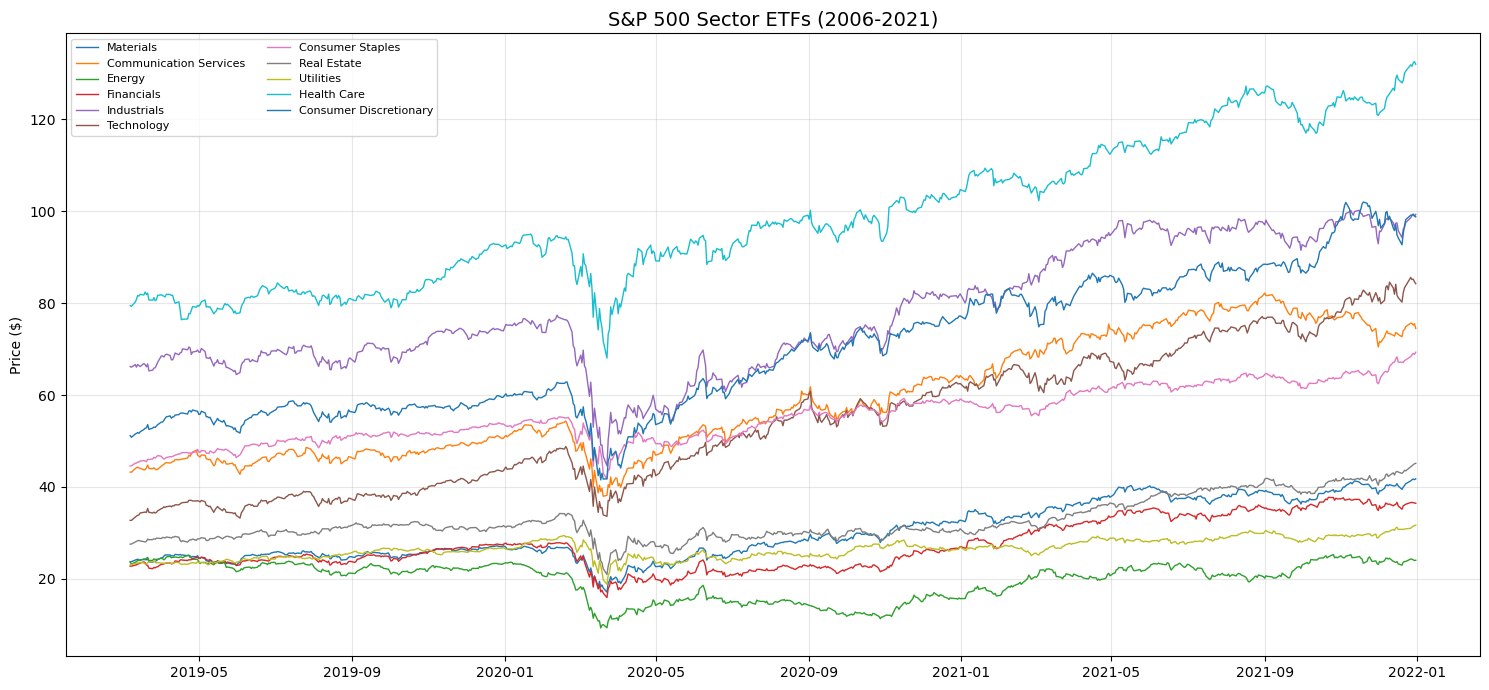

In [3]:
# Visualize sector prices
fig, ax = plt.subplots(figsize=(15, 7))
for ticker in dataset['tickers']:
    name = dataset['ticker_names'][ticker]
    prices = dataset['sector_prices'][ticker]
    ax.plot(prices.index, prices.values, label=name, lw=1)

ax.set_title("S&P 500 Sector ETFs (2006-2021)", fontsize=14)
ax.set_ylabel("Price ($)")
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

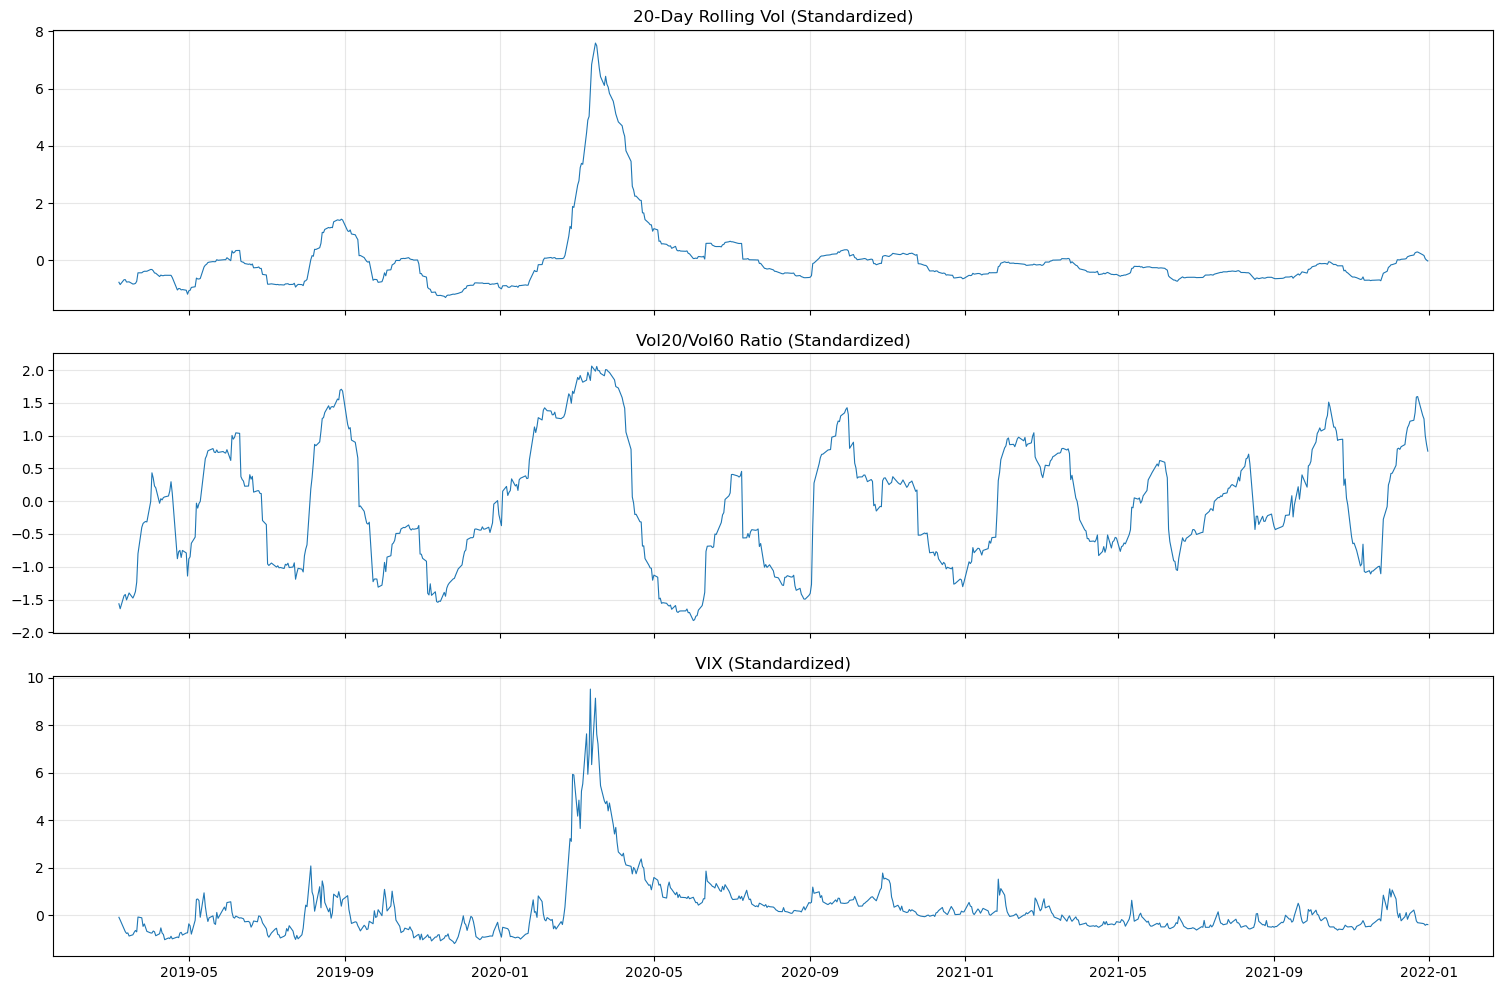

In [4]:
# Visualize volatility features
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
vol_features = dataset['vol_features']

for ax, col, title in zip(axes, vol_features.columns, 
    ['20-Day Rolling Vol (Standardized)', 'Vol20/Vol60 Ratio (Standardized)', 'VIX (Standardized)']):
    ax.plot(vol_features.index, vol_features[col], lw=0.8)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Sliding Window Setup

Generate 10 sliding windows: 5yr train | 1yr validation | 1yr test  
Windows shift by 1 year each (Section 5.2 of paper).

In [5]:
windows = generate_sliding_windows(
    dataset,
    train_years=5,
    val_years=1,
    test_years=1,
    start_year=2006,
    end_year=2022,
)

Generated 1 sliding windows
  Train [2015-2020) | Val 2020 | Test 2021: train=208, val=253, test=252


## 3. MVO Baseline

Run MVO backtest on each test period.  
Uses 60-day lookback, Ledoit-Wolf shrinkage, max Sharpe optimization.

In [6]:
mvo = MVOStrategy(lookback=60, risk_free_rate=0.0)

mvo_results = []
for i, window in enumerate(windows):
    print(f"\nRunning MVO backtest {i+1}/{len(windows)}: {window['label']}")
    test_dates = window['test']['dates']
    
    history = mvo.run_backtest(dataset, test_dates, initial_cash=100_000.0)
    metrics = compute_metrics(history['daily_returns'])
    
    mvo_results.append({
        'window': window,
        'history': history,
        'metrics': metrics,
    })
    
    print(f"  Sharpe: {metrics['sharpe_ratio']:.4f}, "
          f"Annual Return: {metrics['annual_return']:.4f}, "
          f"Max DD: {metrics['max_drawdown']:.4f}")


Running MVO backtest 1/1: Train [2015-2020) | Val 2020 | Test 2021
  Sharpe: 1.1492, Annual Return: 0.1851, Max DD: -0.0865


## 4. DRL Agent (PPO) Training

Train PPO agents on each sliding window.  
The best agent from each window is used to seed the next window.

**Note**: Full training (7.5M timesteps × 10 windows × 5 seeds) takes many hours.  
Below we use reduced settings for a quick demo. Adjust `TOTAL_TIMESTEPS` and `N_SEEDS` for full reproduction.

In [10]:
# ============ CONFIGURATION ============
# For quick demo: reduce timesteps and seeds
# For full paper reproduction: TOTAL_TIMESTEPS=7_500_000, N_SEEDS=5, N_ENVS=10
TOTAL_TIMESTEPS = 100_000   # Paper: 7_500_000
N_SEEDS = 1                  # Paper: 5
N_ENVS = 4                   # Paper: 10
INITIAL_CASH = 100_000.0
LOOKBACK = 60
# =======================================

In [11]:
from src.environment import PortfolioEnv

drl_results = []
best_model = None  # Will be used for warm-starting next window

for w_idx, window in enumerate(windows):
    print(f"\n{'='*70}")
    print(f"Window {w_idx+1}/{len(windows)}: {window['label']}")
    print(f"{'='*70}")
    
    train_dates = window['train']['dates']
    val_dates = window['val']['dates']
    test_dates = window['test']['dates']
    
    # Create validation environment for model selection
    val_env = PortfolioEnv(
        dataset=dataset,
        date_indices=val_dates,
        initial_cash=INITIAL_CASH,
        lookback=LOOKBACK,
    )
    
    # Train N_SEEDS agents with different seeds
    seed_results = []
    for seed in range(N_SEEDS):
        print(f"\n  Training seed {seed+1}/{N_SEEDS}...")
        
        model = create_ppo_agent(
            dataset=dataset,
            train_dates=train_dates,
            n_envs=N_ENVS,
            initial_cash=INITIAL_CASH,
            lookback=LOOKBACK,
            seed=seed * 100 + w_idx,
            pretrained_model=best_model,
            verbose=0,
        )
        
        model = train_agent(
            model,
            total_timesteps=TOTAL_TIMESTEPS,
            val_env=val_env,
            eval_freq=TOTAL_TIMESTEPS // 5,
            verbose=0,
        )
        
        # Evaluate on validation set
        val_history = evaluate_agent(model, dataset, val_dates, INITIAL_CASH, LOOKBACK)
        val_reward = np.sum(val_history['rewards'])
        
        seed_results.append({'model': model, 'val_reward': val_reward})
        print(f"    Validation reward: {val_reward:.4f}")
    
    # Select best seed by validation reward
    best_seed_idx = np.argmax([r['val_reward'] for r in seed_results])
    best_model = seed_results[best_seed_idx]['model']
    print(f"\n  Best seed: {best_seed_idx + 1} (val reward: {seed_results[best_seed_idx]['val_reward']:.4f})")
    
    # Evaluate all seeds on test set, then average
    test_histories = []
    for sr in seed_results:
        test_history = evaluate_agent(sr['model'], dataset, test_dates, INITIAL_CASH, LOOKBACK)
        test_histories.append(test_history)
    
    # Average returns across seeds
    avg_returns = np.mean([h['daily_returns'] for h in test_histories], axis=0)
    avg_history = {
        'dates': test_histories[0]['dates'],
        'daily_returns': avg_returns,
        'portfolio_values': INITIAL_CASH * np.cumprod(1 + avg_returns),
        'weights': np.mean([h['weights'] for h in test_histories], axis=0),
    }
    
    metrics = compute_metrics(avg_returns)
    drl_results.append({
        'window': window,
        'history': avg_history,
        'metrics': metrics,
        'best_model': best_model,
    })
    
    print(f"  Test - Sharpe: {metrics['sharpe_ratio']:.4f}, "
          f"Annual Return: {metrics['annual_return']:.4f}, "
          f"Max DD: {metrics['max_drawdown']:.4f}")


Window 1/1: Train [2015-2020) | Val 2020 | Test 2021

  Training seed 1/1...


/opt/homebrew/Caskroom/miniforge/base/envs/quant/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 1260, but because the `RolloutBuffer` is of size `n_steps * n_envs = 3024`, after every 2 untruncated mini-batches, there will be a truncated mini-batch of size 504
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=756 and n_envs=4)
  warnings.warn(


    Validation reward: 19.7927

  Best seed: 1 (val reward: 19.7927)
  Test - Sharpe: 2.4193, Annual Return: 0.2938, Max DD: -0.0430


## 5. Results Comparison

Aggregate metrics across all backtest windows (Table 2 in paper).

In [12]:
# Aggregate metrics across all windows
metric_keys = list(drl_results[0]['metrics'].keys())

drl_avg_metrics = {}
mvo_avg_metrics = {}

for key in metric_keys:
    drl_values = [r['metrics'][key] for r in drl_results]
    mvo_values = [r['metrics'][key] for r in mvo_results]
    
    if key == 'max_drawdown':
        # Report worst (minimum) max drawdown across all periods
        drl_avg_metrics[key] = np.min(drl_values)
        mvo_avg_metrics[key] = np.min(mvo_values)
    else:
        drl_avg_metrics[key] = np.mean(drl_values)
        mvo_avg_metrics[key] = np.mean(mvo_values)

print_metrics_table(drl_avg_metrics, mvo_avg_metrics, title="Averaged Backtest Results (DRL vs MVO)")


  Averaged Backtest Results (DRL vs MVO)
Metric                                DRL             MVO
-------------------------------------------------------
annual_return                      0.2938          0.1851
cumulative_return                  0.2925          0.1851
annual_volatility                  0.1090          0.1588
sharpe_ratio                       2.4193          1.1492
sortino_ratio                      3.3304          1.6221
calmar_ratio                       6.8406          2.1411
max_drawdown                      -0.0430         -0.0865
omega_ratio                        1.4974          1.2140
skew                              -0.4264         -0.2634
kurtosis                           0.9331          0.7134
tail_ratio                         1.1489          1.1587
daily_var_95                      -0.0104         -0.0161



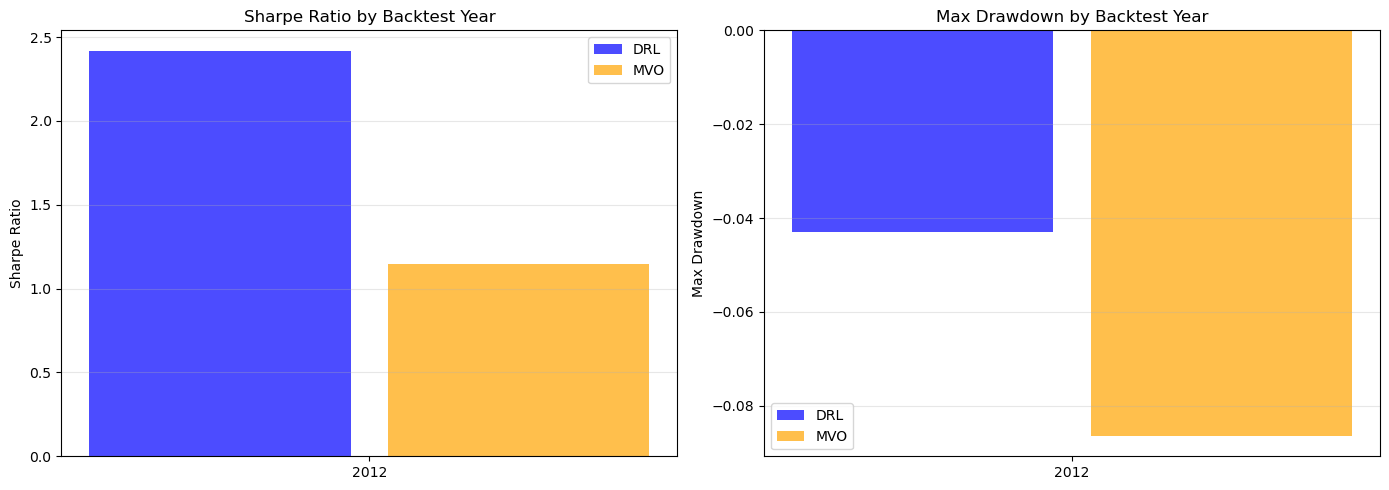

In [13]:
# Per-window Sharpe comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window_labels = [f"{2012 + i}" for i in range(len(windows))]

# Sharpe Ratio
ax = axes[0]
drl_sharpes = [r['metrics']['sharpe_ratio'] for r in drl_results]
mvo_sharpes = [r['metrics']['sharpe_ratio'] for r in mvo_results]
x = np.arange(len(window_labels))
ax.bar(x - 0.2, drl_sharpes, 0.35, label='DRL', color='blue', alpha=0.7)
ax.bar(x + 0.2, mvo_sharpes, 0.35, label='MVO', color='orange', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(window_labels)
ax.set_title('Sharpe Ratio by Backtest Year')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Max Drawdown
ax = axes[1]
drl_dd = [r['metrics']['max_drawdown'] for r in drl_results]
mvo_dd = [r['metrics']['max_drawdown'] for r in mvo_results]
ax.bar(x - 0.2, drl_dd, 0.35, label='DRL', color='blue', alpha=0.7)
ax.bar(x + 0.2, mvo_dd, 0.35, label='MVO', color='orange', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(window_labels)
ax.set_title('Max Drawdown by Backtest Year')
ax.set_ylabel('Max Drawdown')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Plot saved to backtest_comparison.png


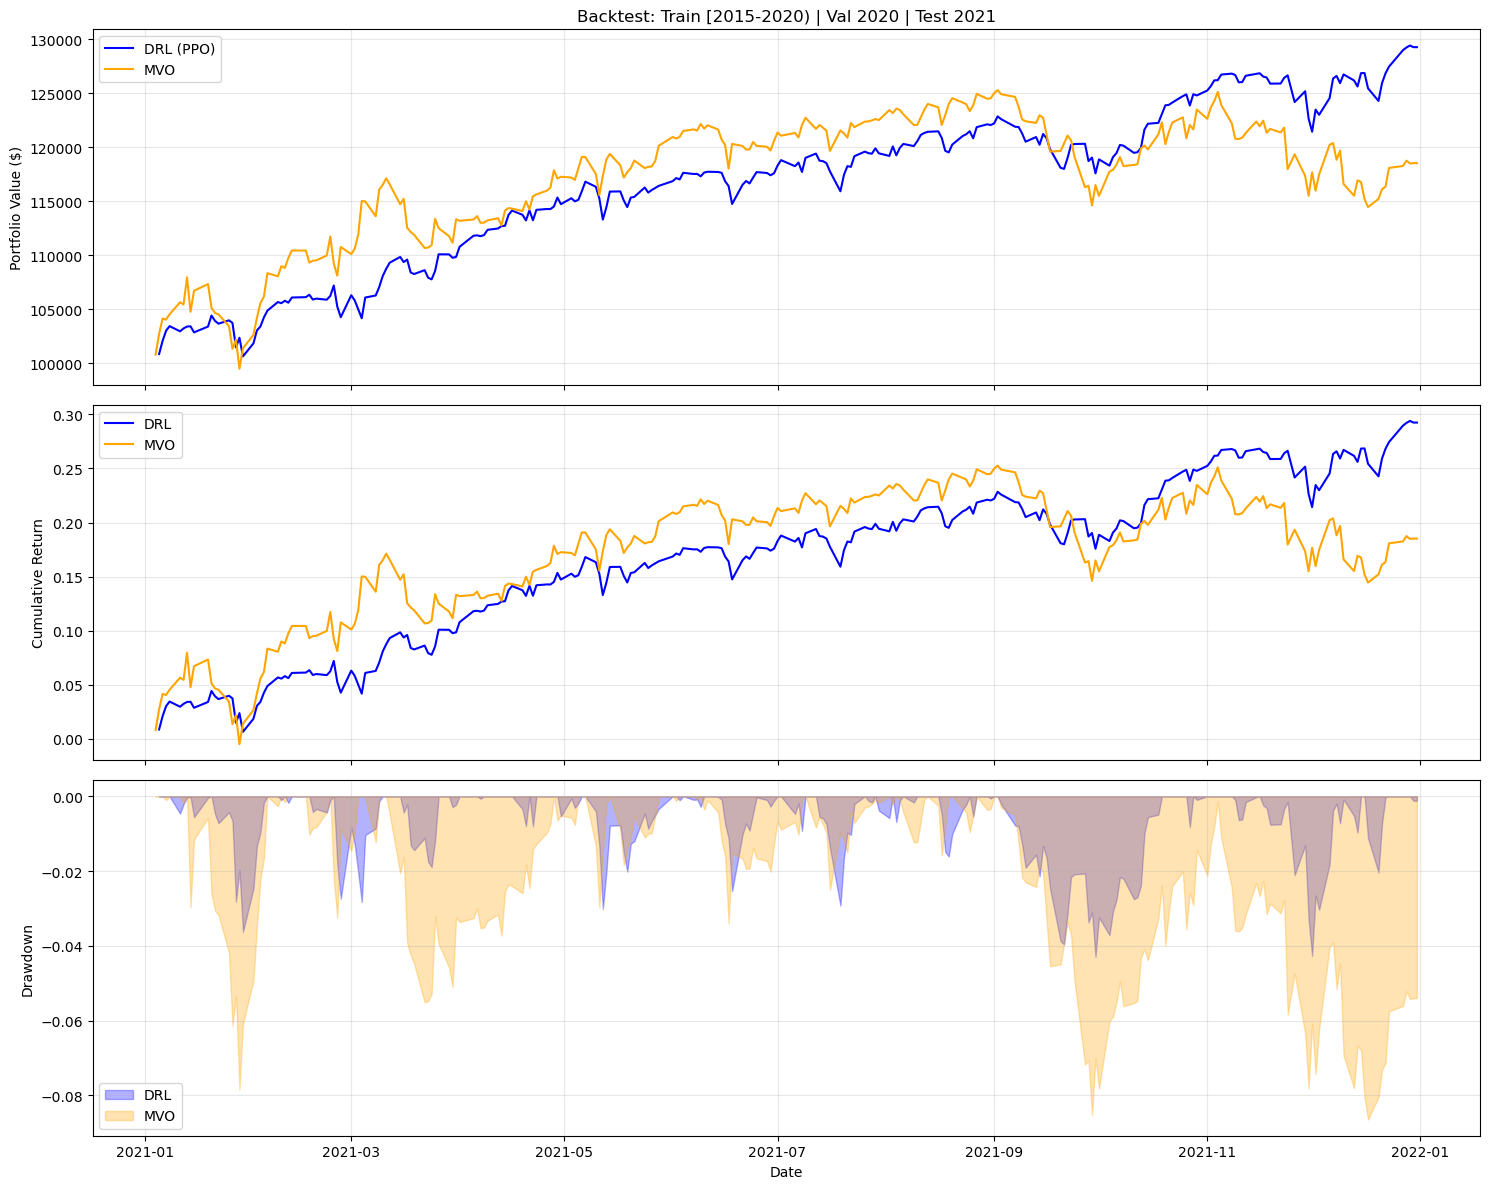

In [14]:
# Detailed plot for a single backtest window (e.g., most recent)
window_idx = -1  # Last window

plot_backtest_comparison(
    drl_results[window_idx]['history'],
    mvo_results[window_idx]['history'],
    title=f"Backtest: {windows[window_idx]['label']}",
    save_path="backtest_comparison.png"
)

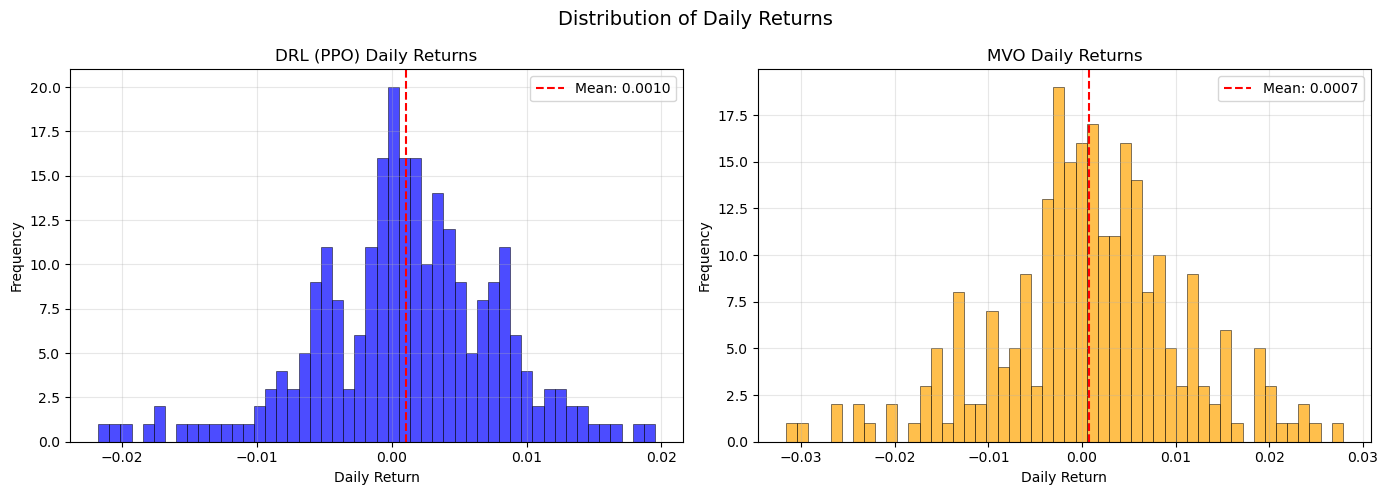

In [15]:
# Daily returns distribution comparison
all_drl_returns = np.concatenate([r['history']['daily_returns'] for r in drl_results])
all_mvo_returns = np.concatenate([r['history']['daily_returns'] for r in mvo_results])

plot_returns_distribution(all_drl_returns, all_mvo_returns)

In [16]:
# Portfolio turnover comparison
drl_turnovers = [np.mean(compute_turnover(r['history']['weights'])) for r in drl_results]
mvo_turnovers = [np.mean(compute_turnover(r['history']['weights'])) for r in mvo_results]

print(f"Average Daily Turnover:")
print(f"  DRL: {np.mean(drl_turnovers):.4f}")
print(f"  MVO: {np.mean(mvo_turnovers):.4f}")
print(f"  Ratio (MVO/DRL): {np.mean(mvo_turnovers)/np.mean(drl_turnovers):.2f}x")

Average Daily Turnover:
  DRL: 0.0134
  MVO: 0.2864
  Ratio (MVO/DRL): 21.37x


## 6. Weight Evolution

Visualize how each strategy allocates across sectors over time.

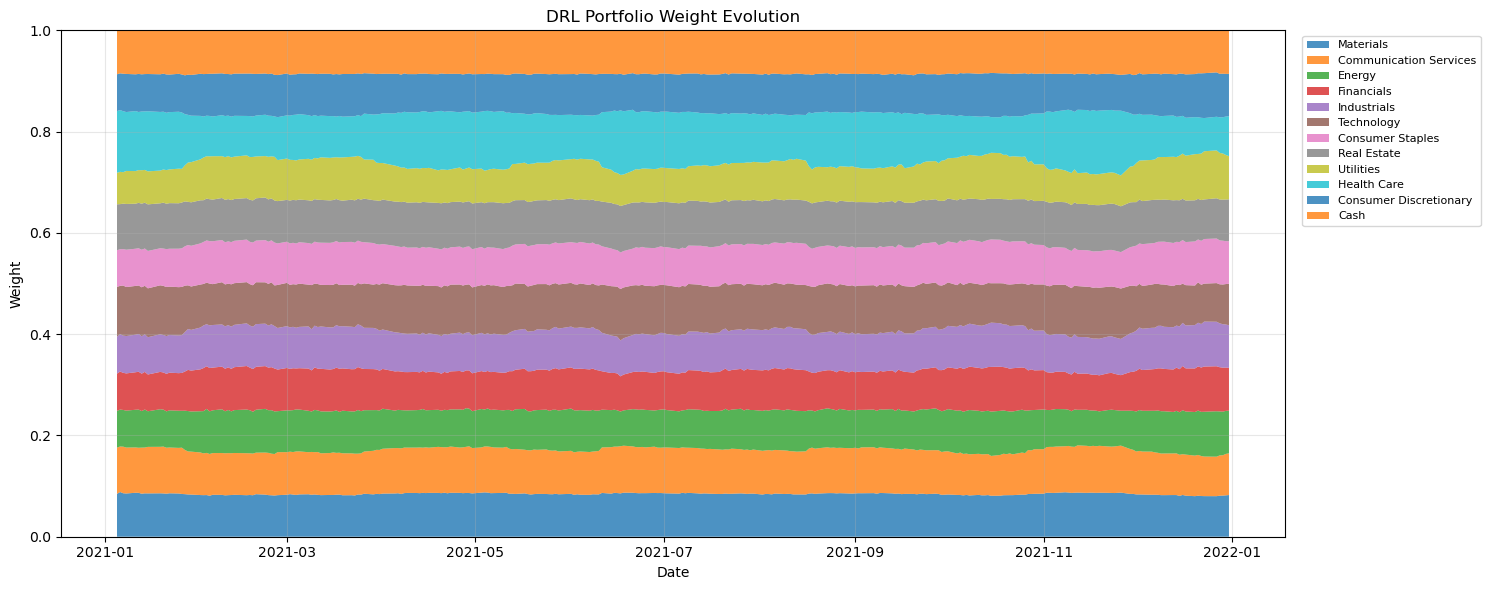

In [17]:
# DRL weight evolution (last window)
plot_weight_evolution(
    drl_results[-1]['history'],
    dataset['ticker_names'],
    dataset['tickers'],
    title="DRL Portfolio Weight Evolution",
)

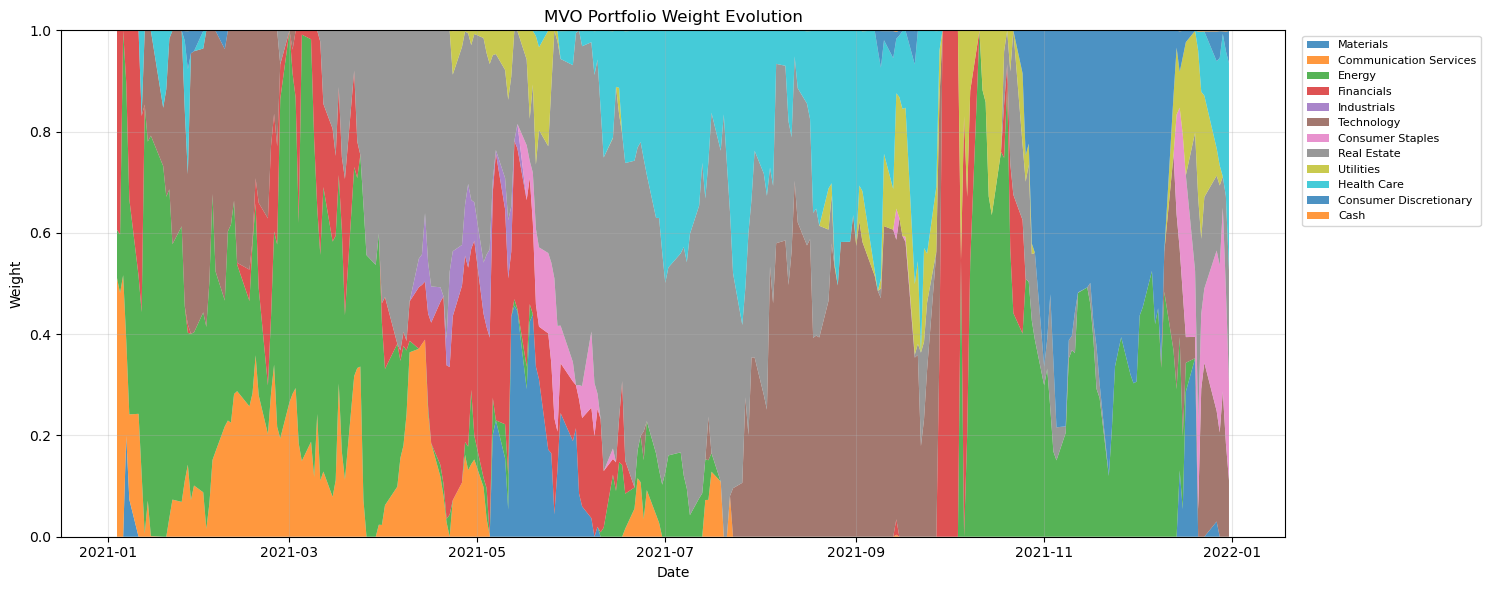

In [18]:
# MVO weight evolution (last window)
# Add cash weight column to MVO weights for plotting
mvo_weights = mvo_results[-1]['history']['weights']
mvo_cash = mvo_results[-1]['history']['cash_weight']
mvo_full_weights = np.column_stack([mvo_weights, mvo_cash])

mvo_plot_history = {
    'dates': mvo_results[-1]['history']['dates'],
    'weights': mvo_full_weights,
}

plot_weight_evolution(
    mvo_plot_history,
    dataset['ticker_names'],
    dataset['tickers'],
    title="MVO Portfolio Weight Evolution",
)

---

## Summary

This notebook implements the full baseline from *Sood et al. (2023)*:

| Component | Implementation |
|---|---|
| **Data** | 11 S&P 500 sector ETFs + VIX + S&P 500 (Yahoo Finance) |
| **State** | [(n+1) × 60] matrix: weights + 60-day log returns + vol features |
| **Action** | Portfolio weights via softmax (long-only, sum=1) |  
| **Reward** | Differential Sharpe Ratio (Moody et al., 1998) |
| **DRL** | PPO (StableBaselines3), 10 vectorized envs, annealed LR |
| **MVO** | Max Sharpe with Ledoit-Wolf shrinkage (PyPortfolioOpt) |
| **Evaluation** | 10 sliding windows [2012-2021], $100k initial, whole shares |

### Next Steps (from your plan):
- [ ] **HMM Model Development**: Replace simple regime detection with Gaussian HMM
- [ ] **HMM Observation Vectors**: Use 20-day rolling vol + moving averages
- [ ] **Sector Volatility Analysis**: Analyze vol differences across sectors
- [ ] **Base Architecture**: Build regime-switching RL architecture